In [21]:
import numpy as np, pandas as pd


index = np.repeat(pd.date_range(start='2025-01-01',end='2025-01-31', freq='1d',inclusive='left'), repeats=24) 

A = np.random.normal(loc=0, scale=1, size=index.shape[0])
B = 2 * A + np.random.normal(loc=0, scale=1, size=len(A))


dataA = pd.DataFrame(data={"A":A, "B":B},index=index)

dataA

,A,B
2025-01-01,1.190646,1.604062
2025-01-01,-0.725849,-0.039663
2025-01-01,-0.632678,-0.122645
2025-01-01,0.153380,0.010295
2025-01-01,0.225749,0.443456
...,...,...
2025-01-30,-0.605877,-0.690343
2025-01-30,1.011740,-0.211903
2025-01-30,-0.411779,-2.190322
2025-01-30,0.283136,-0.258319


In [22]:
dataA_agg = (
    dataA.groupby(
        dataA.index
    )
    .agg(["sum","max"])
    # .reset_index()
)



C1 = 3* dataA_agg[('B','sum')] + np.random.normal(loc=0, scale=1, size=len(dataA_agg[('B','sum')]))
C2 =  dataA_agg[('B','max')]


D = 4 * C1 + np.random.normal(loc=0, scale=1, size=len(C1))
E = np.cumsum(C2)
dataB = pd.DataFrame(data=dict(C=C1, D=D, E=E))
dataB

,C,D,E
2025-01-01,5.990425,25.511479,4.286655
2025-01-02,-54.541252,-218.011190,8.110624
2025-01-03,42.678096,171.635509,12.563455
2025-01-04,5.263736,21.308047,16.137702
2025-01-05,-3.701917,-14.661317,19.881641
2025-01-06,16.885942,67.612287,24.331204
2025-01-07,24.323394,97.762667,30.083560
2025-01-08,0.902400,1.842307,34.101163
2025-01-09,13.126523,51.488621,38.670144
2025-01-10,-25.103348,-99.440919,41.303689


In [23]:
dataA =dataA.reset_index(names="!index")
dataB =dataB.reset_index(names="!index")

In [24]:
import networkx as nx
causal_graphA = nx.DiGraph([('A', 'B')])
causal_graphB = nx.DiGraph([('C', 'D'),('D','E')])

In [25]:
from dowhy import gcm

causal_modelA = gcm.StructuralCausalModel(causal_graphA)
causal_modelB = gcm.StructuralCausalModel(causal_graphB)

In [26]:
from dowhy.gcm.defined_causal_mechanisms import DefinedConditionalStochasticModel


causal_modelB.set_causal_mechanism("E",DefinedConditionalStochasticModel(lambda x: np.cumsum(x)))

In [27]:
auto_assignment_summaryA = gcm.auto.assign_causal_mechanisms(causal_modelA, based_on=dataA,experimental_allow_nans=True)
auto_assignment_summaryB = gcm.auto.assign_causal_mechanisms(causal_modelB, based_on=dataB,experimental_allow_nans=True)

Optionally, we can get more insights from the auto assignment process:

In the real world, the data comes as an opaque stream of values, where we typically don't know how one
variable influences another. The graphical causal models can help us to deconstruct these causal
relationships again, even though we didn't know them before.

## Step 2: Fitting the SCM to the data

With the data at hand and the graph constructed earlier, we can now train the SCM using `fit`:

In [28]:
gcm.fit(causal_modelA, dataA)
gcm.fit(causal_modelB, dataB)

Fitting causal mechanism of node E: 100%|██████████| 3/3 [00:00<00:00, 427.80it/s]


Fitting means, we learn the generative models of the variables in the SCM according to the data.

Once fitted, we can also obtain more insights into the model performances:

Test permutations of given graph: 100%|██████████| 2/2 [00:00<00:00, 1101.30it/s]


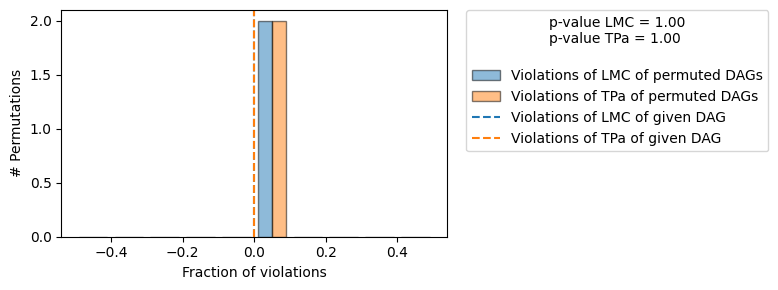

Evaluated the performance of the causal mechanisms and the invertibility assumption of the causal mechanisms and the overall average KL divergence between generated and observed distribution and the graph structure. The results are as follows:

==== Evaluation of Causal Mechanisms ====
The used evaluation metrics are:
- KL divergence (only for root-nodes): Evaluates the divergence between the generated and the observed distribution.
- Mean Squared Error (MSE): Evaluates the average squared differences between the observed values and the conditional expectation of the causal mechanisms.
- Normalized MSE (NMSE): The MSE normalized by the standard deviation for better comparison.
- R2 coefficient: Indicates how much variance is explained by the conditional expectations of the mechanisms. Note, however, that this can be misleading for nonlinear relationships.
- F1 score (only for categorical non-root nodes): The harmonic mean of the precision and recall indicating the goodness of the under

In [29]:
print(gcm.evaluate_causal_model(causal_modelA, dataA))

Test permutations of given graph: 100%|██████████| 6/6 [00:00<00:00, 129.55it/s]


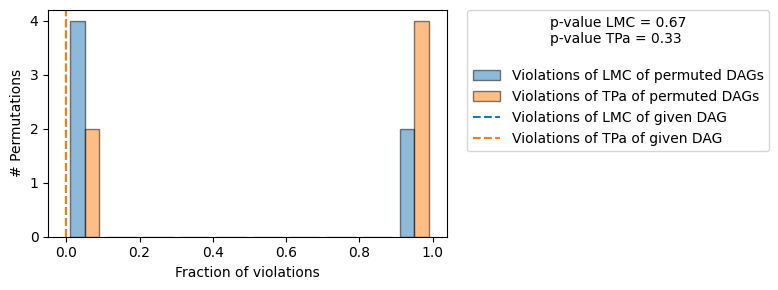

Evaluated the performance of the causal mechanisms and the invertibility assumption of the causal mechanisms and the overall average KL divergence between generated and observed distribution and the graph structure. The results are as follows:

==== Evaluation of Causal Mechanisms ====
The used evaluation metrics are:
- KL divergence (only for root-nodes): Evaluates the divergence between the generated and the observed distribution.
- Mean Squared Error (MSE): Evaluates the average squared differences between the observed values and the conditional expectation of the causal mechanisms.
- Normalized MSE (NMSE): The MSE normalized by the standard deviation for better comparison.
- R2 coefficient: Indicates how much variance is explained by the conditional expectations of the mechanisms. Note, however, that this can be misleading for nonlinear relationships.
- F1 score (only for categorical non-root nodes): The harmonic mean of the precision and recall indicating the goodness of the under

In [30]:
print(gcm.evaluate_causal_model(causal_modelB, dataB))

In [31]:
from dowhy.gcm.defined_causal_mechanisms import AggregationMechanism


links = {
    ("B", "C","!index"):"sum"
    ,
    ("B", "C2","!index"):"max"
    
}

In [32]:
causal_model_composite = gcm.StructuralCausalModelComposite(
    [causal_modelA, causal_modelB], links=links
)

## Step 3: Answering a causal query based on the SCM

The last step, answering a causal question, is our actual goal. E.g. we could ask the question "What will happen to the variable Z if I intervene on Y?".

This can be done via the `interventional_samples` function. Here’s how:

In [46]:
samples = gcm.interventional_samples(causal_model_composite,
                                     {'B': lambda B: B },
                                    observed_data= dataA[["!index","A"]])

[pd.DataFrame({k:v for k,v in samples.items() if len(v)== length}) for length in set([ len(sv) for sv  in samples.values()])]

[        !index         A         B
 0   2025-01-01  1.190646  3.119514
 1   2025-01-01 -0.725849 -2.682742
 2   2025-01-01 -0.632678 -1.477346
 3   2025-01-01  0.153380 -0.065749
 4   2025-01-01  0.225749  0.392550
 ..         ...       ...       ...
 715 2025-01-30 -0.605877 -1.689368
 716 2025-01-30  1.011740  2.357002
 717 2025-01-30 -0.411779 -2.368482
 718 2025-01-30  0.283136  1.443679
 719 2025-01-30  1.414756  3.810985
 
 [720 rows x 3 columns],
             C        C2          D           E
 0    3.349364  4.537963  13.073305   13.073305
 1  -13.341698  5.014595 -53.735837  -40.662532
 2   14.866367  4.846865  59.030794   18.368262
 3   11.223983  4.092559  44.723007    63.09127
 4    2.481636  2.972111  10.085046   73.176315
 5   -0.393094  3.500425   0.605022   73.781337
 6   13.163925  5.976461  52.935467  126.716805
 7   -6.631959  4.300688 -25.559517  101.157288
 8   18.984212  4.032602  75.565234  176.722522
 9   -2.544627  4.171729 -10.904701  165.817821
 10   2.20441